# Base ideia

In [1]:
from data.syntatic import step_wise
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
num_points = 10000

x,y = step_wise(num_points=num_points, f = lambda x: (4*x - 2)**2, mode = 'cosine')

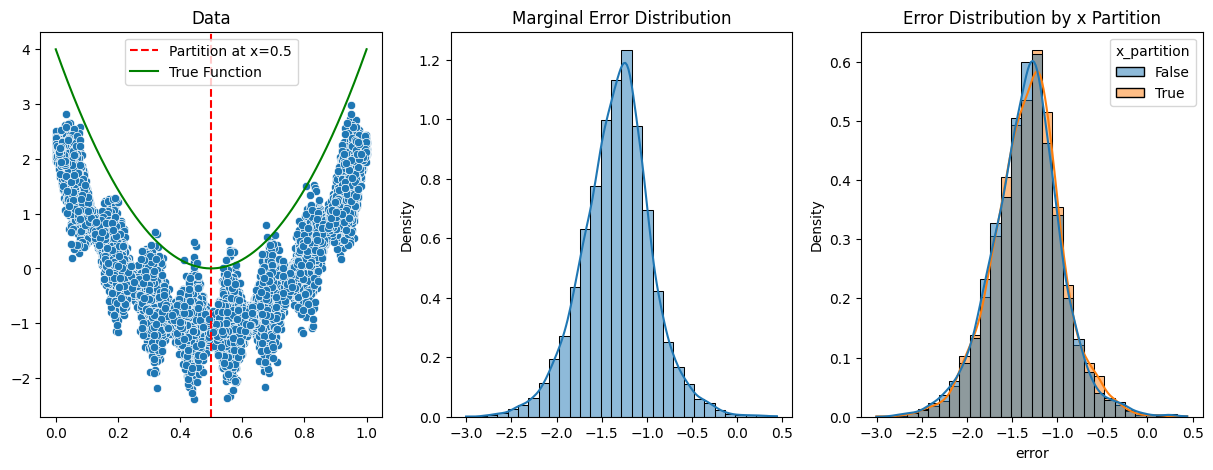

In [3]:
fig,axs = plt.subplots(1,3,figsize=(15,5))

# Plot the data
sns.scatterplot(x=x,y=y,ax=axs[0])
axs[0].set_title("Data")
axs[0].axvline(x=0.5, color='red', linestyle='--', label='Partition at x=0.5')
pred_y = (4*x - 2)**2 
sns.lineplot(x=x, y=pred_y, color='green', label='True Function', ax=axs[0])
axs[0].legend()


# plot the marginal error 
error = y - (4*x - 2)**2
sns.histplot(error, bins=30, kde=True, ax=axs[1], stat='density')
axs[1].set_title("Marginal Error Distribution")

# plot the error as a function of x
df = pd.DataFrame({'x': x, 'error': error})
df['x_partition'] = (x < 0.5) 
sns.histplot(data=df, x='error', hue='x_partition', bins=30, kde=True, ax=axs[2],stat='density')
axs[2].set_title("Error Distribution by x Partition")

plt.show()

In [4]:
def divide_equal_bins(x, num_bins):
    x = np.array(x)
    x = np.sort(x)
    bins = [x[int(i * len(x) / num_bins)] for i in range(1, num_bins)]
    bins = np.array(bins)
    return bins

In [5]:
from scipy.stats import gaussian_kde
# Compute the density estimates
density = gaussian_kde(error,bw_method='silverman')

# Interval for x values
x_vals = divide_equal_bins(error, num_bins=1000)
predep_error = 0
for i in range(len(x_vals)-1):
    start_x = x_vals[i]
    end_x = x_vals[i+1]
    middle_x = (start_x + end_x) / 2
    dx = end_x - start_x
    predep_error += dx * density(middle_x) ** 2
print(f"PreDEP Error: {predep_error[0]}")

PreDEP Error: 0.7734132096893467


In [6]:
predep_partition_error_total = 0
for partition in [0, 1]:
    partition_error = error[df['x_partition'] == partition]
    density_partition = gaussian_kde(partition_error,bw_method='silverman')
    predep_partition_error = 0
    x_vals = divide_equal_bins(partition_error, num_bins=1000)
    
    for i in range(len(x_vals)-1):
        start_x = x_vals[i]
        end_x = x_vals[i+1]
        middle_x = (start_x + end_x) / 2
        dx = end_x - start_x
        predep_partition_error += dx * density_partition(middle_x) ** 2

    print(f"PreDEP Error for x < 0.5 = {partition}: {predep_partition_error[0]}")
    predep_partition_error_total += predep_partition_error[0] * 0.5

print (f"Total PreDEP Error across partitions: {predep_partition_error_total}")

PreDEP Error for x < 0.5 = 0: 0.770394029647746
PreDEP Error for x < 0.5 = 1: 0.768229811016217
Total PreDEP Error across partitions: 0.7693119203319815


In [7]:
print(f"PreDEP Error Ratio (Partitioned / Marginal): {predep_partition_error_total / predep_error[0]}")

PreDEP Error Ratio (Partitioned / Marginal): 0.9946971563118083


# Model

In [8]:
import torch
from models.estimation import EstimationModel

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
model = EstimationModel(input_dim=1, hidden_dim=128, output_dim=1, num_partitions=3, num_gaussians=1)
model.to(device)

EstimationModel(
  (ev_model): ExpectedValue_MLP(
    (model): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=1, bias=True)
    )
  )
  (partition_model): PartitionModel(
    (partitions): Sequential(
      (0): Linear(in_features=1, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=128, bias=True)
      (5): ReLU()
      (6): Linear(in_features=128, out_features=3, bias=True)
    )
    (density_estimators): ModuleList(
      (0-2): 3 x DensityEstimator()
    )
  )
)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [12]:
num_points = 10000
num_epochs = 10000

In [13]:
model.train()
for epoch in range(num_epochs):
    x,y = step_wise(num_points=num_points, f = lambda x: (4*x - 2)**2,start_std=0.1,end_std=0.5,mode='cosine')
    inputs = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)
    targets = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)
    
    loss = model.compute_loss(inputs, targets)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 1000 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [1000/10000], Loss: 0.3491
Epoch [2000/10000], Loss: 0.2787
Epoch [3000/10000], Loss: 0.2143
Epoch [4000/10000], Loss: 0.1585
Epoch [5000/10000], Loss: 0.1641
Epoch [6000/10000], Loss: 0.1377
Epoch [7000/10000], Loss: 0.1395
Epoch [8000/10000], Loss: 0.1301
Epoch [9000/10000], Loss: 0.1776
Epoch [10000/10000], Loss: 0.1259


In [14]:
import matplotlib.colors as mcolors

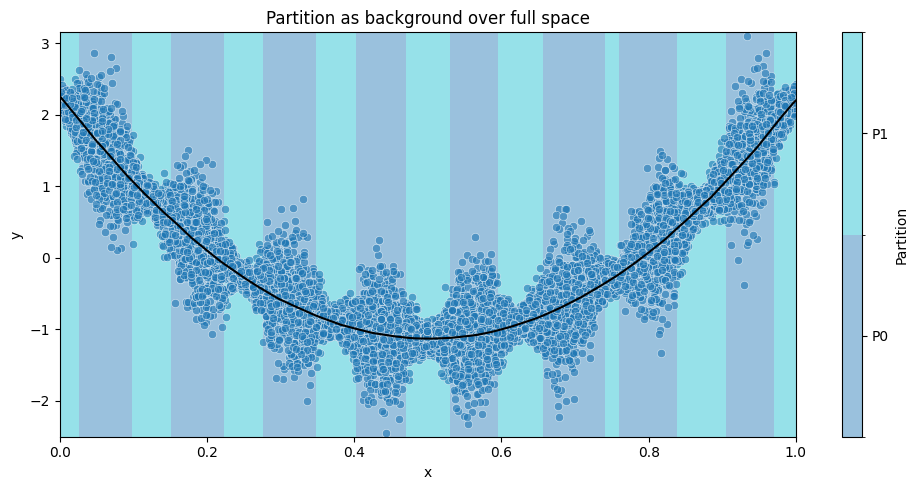

In [15]:
# Grid denso
X_vis = torch.linspace(0, 1, 10000).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    logits = model.partition_model.get_partion_logits(X_vis)
    probs = torch.softmax(logits, dim=1)  # (N, K)

    # Entropia
    partiotions = torch.argmax(probs,dim=1)
    partiotions = partiotions.cpu().numpy()

    predictions = model(X_vis).cpu().numpy()

K = partiotions.max() + 1          # number of partitions

# 1. Discrete colormap with exactly K colors
base_cmap = plt.get_cmap('tab10', K)   # or 'Set2', 'Paired', etc.
cmap = mcolors.ListedColormap(
    [base_cmap(i) for i in range(K)]
)
# Boundaries sit between integer class indices
bounds = np.arange(-0.5, K + 0.5, 1)
norm  = mcolors.BoundaryNorm(bounds, cmap.N)

# 2. Build the mesh exactly as before
X_repeat       = np.repeat(X_vis.cpu().numpy(), 50, axis=1)
Y_repeat       = np.linspace(y.min(), y.max(), 50)
partions_repeat = np.repeat(partiotions[:, None], 50, axis=1)

# 3. Plot
fig, ax = plt.subplots(figsize=(10, 5))

mesh = ax.pcolormesh(
    X_repeat,
    np.tile(Y_repeat, (len(X_vis), 1)),
    partions_repeat,
    shading='auto',
    cmap=cmap,
    norm=norm,
    alpha=0.45,
)

sns.scatterplot(x=x, y=y, alpha=0.6, ax=ax)
ax.plot(X_vis.cpu().numpy(), predictions, color='black', lw=1.5)

# 4. Categorical colorbar: one tick per class
cbar = fig.colorbar(mesh, ax=ax, ticks=np.arange(K))
cbar.set_label("Partition")
cbar.ax.set_yticklabels([f"P{i}" for i in range(K)])

ax.set_title("Partition as background over full space")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

In [16]:
with torch.no_grad():
    logits = model.partition_model.get_partion_logits(inputs)
    probs = torch.softmax(logits, dim=1)
    predicted_partitions = torch.argmax(probs, dim=1)

    y_out = model(inputs).cpu().numpy()
    error = (targets.cpu().numpy() - y_out).flatten()

df = pd.DataFrame({
    'x': inputs.cpu().numpy().flatten(),
    'y': targets.cpu().numpy().flatten(),
    'error': error,
    'class': predicted_partitions.cpu().numpy().flatten()
})

e:\Python\PREDEP_Heteroscedastic\.venv\Lib\site-packages\numpy\lib\_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


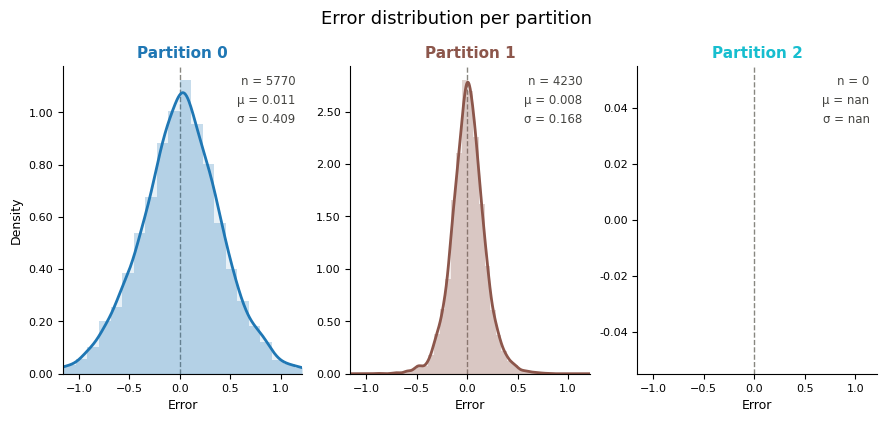

In [17]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from scipy.stats import gaussian_kde
import seaborn as sns

K = model.partition_model.num_partitions

# ── palette: same tab10 colors as the partition background plot ──────────
base_cmap = plt.get_cmap('tab10', K)
colors = [base_cmap(k) for k in range(K)]

# ── global x-range for shared axis ──────────────────────────────────────
x_min, x_max = df['error'].quantile(0.005), df['error'].quantile(0.995)
x_pad = (x_max - x_min) * 0.08
x_lim = (x_min - x_pad, x_max + x_pad)

fig, axs = plt.subplots(
    1, K,
    figsize=(3.5 * K, 4),
    sharey=False,   # each panel has its own density scale
    sharex=True
)
if K == 1:
    axs = [axs]

for k, ax in enumerate(axs):
    subset = df[df['class'] == k]['error'].dropna()
    c = colors[k]

    # histogram
    ax.hist(
        subset, bins=30,
        density=True,
        color=c, alpha=0.25,
        linewidth=0,
    )

    # smooth KDE on top
    if len(subset) > 5:
        xs = np.linspace(*x_lim, 400)
        kde = gaussian_kde(subset, bw_method='scott')
        ax.plot(xs, kde(xs), color=c, linewidth=2)
        ax.fill_between(xs, kde(xs), alpha=0.10, color=c)

    # zero reference line
    ax.axvline(0, color='#888780', linewidth=1, linestyle='--', zorder=0)

    # stats annotation
    mu, sigma, n = subset.mean(), subset.std(), len(subset)
    ax.text(
        0.97, 0.97,
        f"n = {n}\nμ = {mu:.3f}\nσ = {sigma:.3f}",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=8.5,
        color='#444441',
        linespacing=1.6,
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='none', alpha=0.7),
    )

    # styling
    ax.set_title(f"Partition {k}", fontsize=11, color=c, fontweight='bold')
    ax.set_xlabel("Error", fontsize=9)
    ax.set_xlim(x_lim)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel("Density" if k == 0 else "", fontsize=9)

fig.suptitle("Error distribution per partition", fontsize=13, y=1.02)
plt.show()

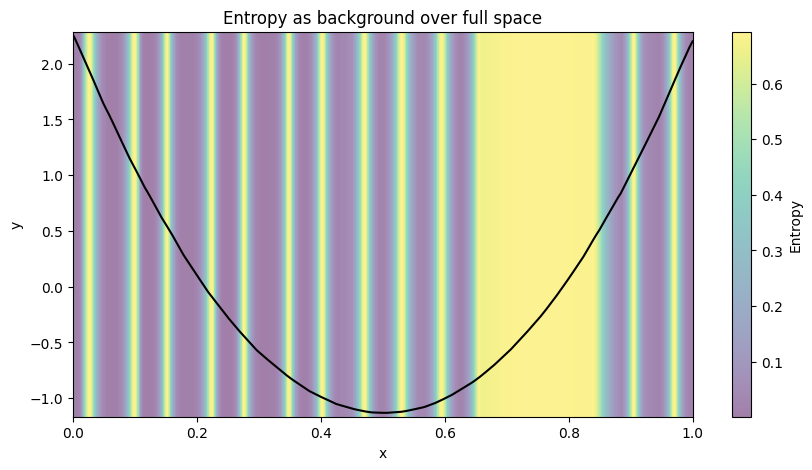

In [18]:
# Grid denso
X_vis = torch.linspace(0, 1, 1000).unsqueeze(1).to(device)

model.eval()
with torch.no_grad():
    logits = model.partition_model.get_partion_logits(X_vis)
    probs = torch.softmax(logits, dim=1)  # (N, K)

    # Entropia
    entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=1)  # (N,)
    entropy = entropy.cpu().numpy()

    predictions = model(X_vis).cpu().numpy()

plt.figure(figsize=(10,5))

# Background (faixa vertical repetida)
X_repeat = np.repeat(X_vis.cpu().numpy(), 50, axis=1)
Y_repeat = np.linspace(predictions.min(), predictions.max(), 50)

entropy_repeat = np.repeat(entropy[:, None], 50, axis=1)

plt.pcolormesh(
    X_repeat,
    np.tile(Y_repeat, (len(X_vis), 1)),
    entropy_repeat,
    shading='auto',
    cmap='viridis',
    alpha=0.5
)

# Curva do modelo
plt.plot(X_vis.cpu().numpy(), predictions, color='black')

plt.colorbar(label="Entropy")
plt.title("Entropy as background over full space")
plt.xlabel("x")
plt.ylabel("y")

plt.show()